# IN403 – Unit 3: Bayesian vs Neural Network for Cancer Screening
**Author:** Shubham Raj | **Course:** IN403 – Deep Learning | **Date:** July 2026

In this notebook I compare a Gaussian Naïve Bayes model and a PyTorch MLP for early skin-cancer screening. I evaluate both on accuracy, precision, recall, F1-score, and ROC-AUC, then recommend which model is safer to deploy first in a clinical setting.

## 1. Setup
Importing all required libraries. The `seaborn` import is commented out since I use matplotlib directly.

In [18]:
# !pip -q install torch scikit-learn pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Understanding and Preparation

The dataset has 5 input features and one binary target (`cancer`: 1 = malignant, 0 = benign). Each feature maps to a known clinical risk indicator used in dermatology:

| Feature | Clinical Risk Link |
|---|---|
| `age` | Risk increases with age |
| `lesion_size` | Larger lesions are more suspicious |
| `color_irregular` | Color variation is a key ABCDE melanoma criterion |
| `border_irregular` | Irregular borders indicate atypical lesions |
| `prior_history` | Repeat diagnoses raise recurrence probability |

The target variable `cancer` is what I'm predicting — whether a patient's lesion is malignant.

In [19]:
df = pd.read_csv('skin_cancer_bayes.csv')
print('Shape:', df.shape)
print('Class distribution:')
print(df['cancer'].value_counts())
display(df.head(10))
df.describe()

Shape: (3000, 6)
Class distribution:
cancer
0    1501
1    1499
Name: count, dtype: int64


,age,lesion_size,color_irregular,border_irregular,prior_history,cancer
0,76,3.77,1,0,0,0
1,24,6.88,0,0,2,1
2,30,5.52,1,1,0,1
3,35,2.20,1,1,2,1
4,31,2.56,1,0,2,0
5,75,5.32,0,1,1,0
6,80,4.22,0,0,2,1
7,59,9.29,1,1,2,1
8,20,6.07,1,0,0,1
9,24,3.93,0,0,0,1


,age,lesion_size,color_irregular,border_irregular,prior_history,cancer
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,53.161667,5.986807,0.505667,0.495667,0.990667,0.499667
std,20.898416,2.028950,0.500051,0.500065,0.816171,0.500083
min,18.000000,-0.720000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,4.580000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,5.980000,1.000000,0.000000,1.000000,0.000000
75%,71.000000,7.350000,1.000000,1.000000,2.000000,1.000000
max,89.000000,13.770000,1.000000,1.000000,2.000000,1.000000


### 2.1 Missing Value Check
Making sure there are no nulls before splitting.

In [20]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age                 0
lesion_size         0
color_irregular     0
border_irregular    0
prior_history       0
cancer              0
dtype: int64


### 2.2 Exploratory Visualizations
I want to see how `age` and `lesion_size` separate the two classes before modeling.

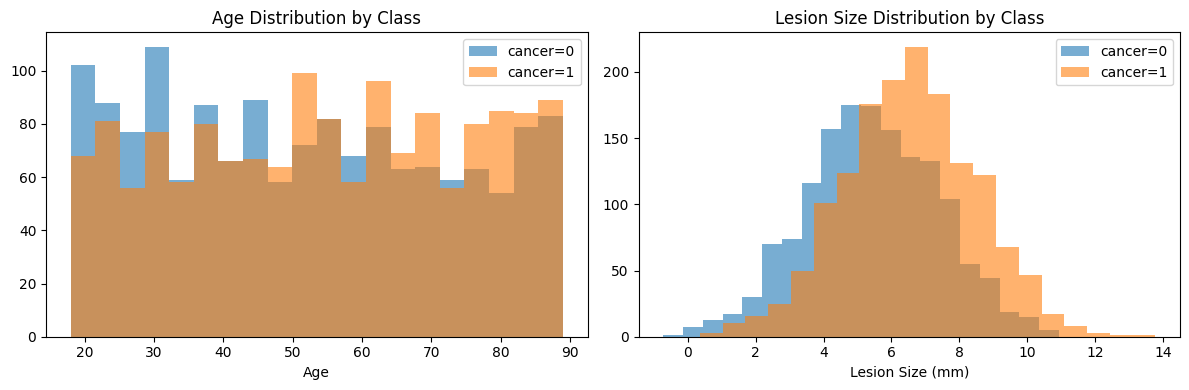

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by class
for label, grp in df.groupby('cancer'):
    axes[0].hist(grp['age'], bins=20, alpha=0.6, label=f'cancer={label}')
axes[0].set_title('Age Distribution by Class')
axes[0].set_xlabel('Age')
axes[0].legend()

# Lesion size distribution by class
for label, grp in df.groupby('cancer'):
    axes[1].hist(grp['lesion_size'], bins=20, alpha=0.6, label=f'cancer={label}')
axes[1].set_title('Lesion Size Distribution by Class')
axes[1].set_xlabel('Lesion Size (mm)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 Train / Test Split
I use an 80/20 stratified split to preserve class proportions in both sets.

In [22]:
X = df.drop(columns=['cancer'])
y = df['cancer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test  class balance: {y_test.value_counts().to_dict()}')

Train size: 2400  |  Test size: 600
Train class balance: {0: 1201, 1: 1199}
Test  class balance: {1: 300, 0: 300}


## 3. Bayesian Model – Gaussian Naïve Bayes

I'm using `GaussianNB` because it's the simplest probabilistic classifier for numeric tabular data. It applies Bayes' theorem assuming each feature is conditionally independent and Gaussian within each class:

> *P(cancer | features) ∝ P(cancer) × ∏ P(featureᵢ | cancer)*

The key advantage for a clinical setting is `predict_proba` — it gives an actual probability score per patient, not just a binary label.

### 3.1 Train

In [23]:
nb = GaussianNB()
nb.fit(X_train, y_train)
print('Gaussian Naïve Bayes trained.')

Gaussian Naïve Bayes trained.


### 3.2 Evaluation – All Required Metrics

In [24]:
nb_pred = nb.predict(X_test)
nb_proba = nb.predict_proba(X_test)[:, 1]  # probability of cancer=1

nb_acc  = accuracy_score(y_test, nb_pred)
nb_prec = precision_score(y_test, nb_pred)
nb_rec  = recall_score(y_test, nb_pred)
nb_f1   = f1_score(y_test, nb_pred)
nb_auc  = roc_auc_score(y_test, nb_proba)

print('===== Gaussian Naïve Bayes – Classification Report =====')
print(classification_report(y_test, nb_pred, target_names=['Benign', 'Cancer']))
print(f'Accuracy : {nb_acc:.4f}')
print(f'Precision: {nb_prec:.4f}')
print(f'Recall   : {nb_rec:.4f}')
print(f'F1-Score : {nb_f1:.4f}')
print(f'ROC-AUC  : {nb_auc:.4f}')

===== Gaussian Naïve Bayes – Classification Report =====
              precision    recall  f1-score   support

      Benign       0.67      0.62      0.64       300
      Cancer       0.64      0.69      0.67       300

    accuracy                           0.65       600
   macro avg       0.65      0.65      0.65       600
weighted avg       0.65      0.65      0.65       600

Accuracy : 0.6533
Precision: 0.6429
Recall   : 0.6900
F1-Score : 0.6656
ROC-AUC  : 0.7106


### 3.3 Confusion Matrix

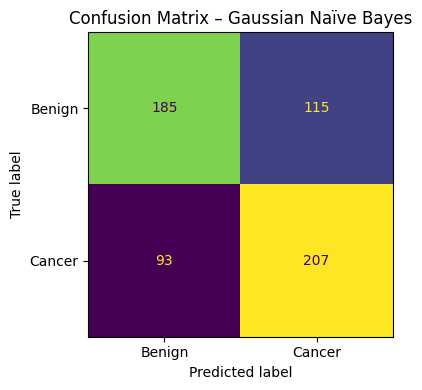

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, nb_pred),
                       display_labels=['Benign', 'Cancer']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix – Gaussian Naïve Bayes')
plt.tight_layout()
plt.show()

### 3.4 Probability Output Interpretation
Below I plot how the predicted probabilities distribute across true benign and cancer cases.

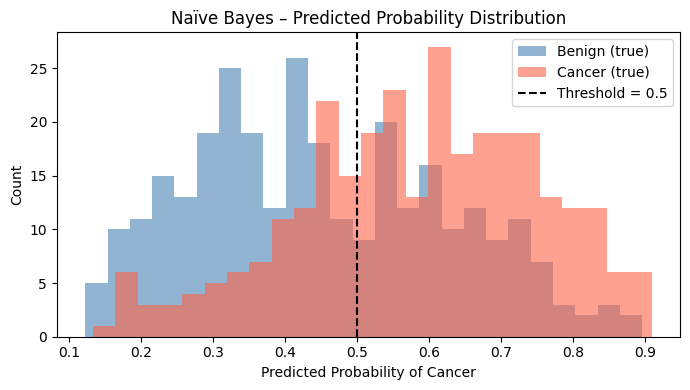

Sample probability outputs:


,True Label,P(cancer)
0,1,0.832
1,1,0.654
2,0,0.659
3,1,0.485
4,0,0.845
5,1,0.411
6,1,0.546
7,1,0.666
8,0,0.640
9,1,0.840


In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nb_proba[y_test == 0], bins=25, alpha=0.6, label='Benign (true)', color='steelblue')
ax.hist(nb_proba[y_test == 1], bins=25, alpha=0.6, label='Cancer (true)', color='tomato')
ax.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
ax.set_xlabel('Predicted Probability of Cancer')
ax.set_ylabel('Count')
ax.set_title('Naïve Bayes – Predicted Probability Distribution')
ax.legend()
plt.tight_layout()
plt.show()

# Sample probability outputs
prob_df = pd.DataFrame({
    'True Label': y_test.values,
    'P(cancer)': np.round(nb_proba, 3)
}).head(10)
print('Sample probability outputs:')
display(prob_df)

**What these scores mean for a clinician:**

A patient with P(cancer) = 0.90 should be fast-tracked for biopsy. A patient at 0.08 can be monitored routinely. Most importantly, a clinician can lower the threshold below 0.5 — say to 0.3 — to catch more true positives at the cost of more follow-up referrals. This threshold adjustment is transparent and defensible, which matters in a clinical context.

## 4. Neural Network – PyTorch MLP

I'm building a small feedforward network for this binary classification task. The architecture follows the assignment spec:

```
Input(n_features) → Linear(32) → ReLU → Dropout(0.2) → Linear(16) → ReLU → Linear(1) → Sigmoid
```

I use BCELoss and Adam (lr=0.001) for 20 epochs. Feature scaling with `StandardScaler` is required here since neural networks are sensitive to input magnitude — unlike GaussianNB.

### 4.1 Scale Features and Build Tensors

In [27]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Convert to PyTorch tensors
Xt = torch.tensor(X_train_s, dtype=torch.float32)
yt = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
Xv = torch.tensor(X_test_s,  dtype=torch.float32)
yv = torch.tensor(y_test.values,  dtype=torch.float32).view(-1, 1)

# DataLoader for mini-batch training
train_ds = TensorDataset(Xt, yt)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

print(f'Train tensors: {Xt.shape}  |  Test tensors: {Xv.shape}')

Train tensors: torch.Size([2400, 5])  |  Test tensors: torch.Size([600, 5])


### 4.2 Model Architecture

In [28]:
class CancerMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


n_features = Xt.shape[1]
model = CancerMLP(n_features)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params}')

CancerMLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
    (6): Sigmoid()
  )
)
Trainable parameters: 737


### 4.3 Training Loop
I print loss every 5 epochs and plot the full train/val loss curve to check for overfitting.

Epoch  5/20  Train Loss: 0.6152  Val Loss: 0.6308
Epoch 10/20  Train Loss: 0.6102  Val Loss: 0.6316
Epoch 15/20  Train Loss: 0.6112  Val Loss: 0.6309
Epoch 20/20  Train Loss: 0.6065  Val Loss: 0.6331


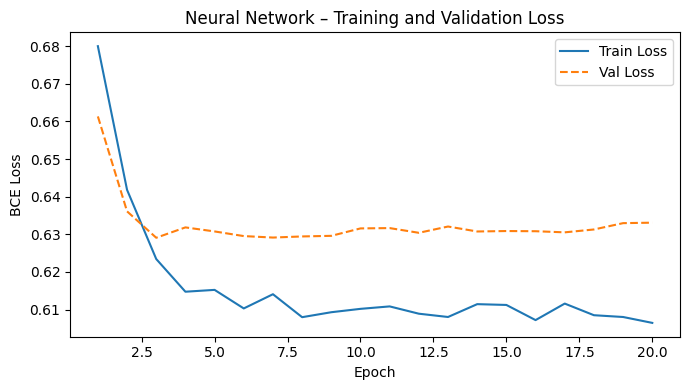

In [29]:
EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(Xv), yv).item()
    val_losses.append(val_loss)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:2d}/{EPOCHS}  Train Loss: {train_losses[-1]:.4f}  Val Loss: {val_losses[-1]:.4f}')

# Loss curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses,  label='Val Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Neural Network – Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

### 4.4 Evaluation – Same Metrics as Bayesian Model

In [30]:
model.eval()
with torch.no_grad():
    nn_proba = model(Xv).numpy().ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

nn_acc  = accuracy_score(y_test, nn_pred)
nn_prec = precision_score(y_test, nn_pred)
nn_rec  = recall_score(y_test, nn_pred)
nn_f1   = f1_score(y_test, nn_pred)
nn_auc  = roc_auc_score(y_test, nn_proba)

print('===== Neural Network – Classification Report =====')
print(classification_report(y_test, nn_pred, target_names=['Benign', 'Cancer']))
print(f'Accuracy : {nn_acc:.4f}')
print(f'Precision: {nn_prec:.4f}')
print(f'Recall   : {nn_rec:.4f}')
print(f'F1-Score : {nn_f1:.4f}')
print(f'ROC-AUC  : {nn_auc:.4f}')

===== Neural Network – Classification Report =====
              precision    recall  f1-score   support

      Benign       0.67      0.60      0.63       300
      Cancer       0.64      0.71      0.67       300

    accuracy                           0.65       600
   macro avg       0.65      0.65      0.65       600
weighted avg       0.65      0.65      0.65       600

Accuracy : 0.6517
Precision: 0.6366
Recall   : 0.7067
F1-Score : 0.6698
ROC-AUC  : 0.7036


### 4.5 Confusion Matrix

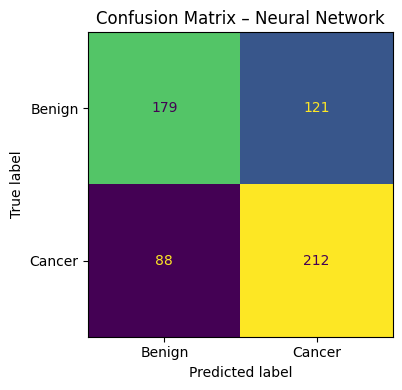

In [31]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, nn_pred),
                       display_labels=['Benign', 'Cancer']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix – Neural Network')
plt.tight_layout()
plt.show()

## 5. Model Comparison

Now I'll put both models side by side across all metrics and think through what the differences mean clinically.

### 5.1 Metrics Summary

In [32]:
comparison = pd.DataFrame([
    {
        'Model':     'Gaussian Naïve Bayes',
        'Accuracy':  round(nb_acc,  4),
        'Precision': round(nb_prec, 4),
        'Recall':    round(nb_rec,  4),
        'F1-Score':  round(nb_f1,   4),
        'ROC-AUC':   round(nb_auc,  4),
    },
    {
        'Model':     'Neural Network (MLP)',
        'Accuracy':  round(nn_acc,  4),
        'Precision': round(nn_prec, 4),
        'Recall':    round(nn_rec,  4),
        'F1-Score':  round(nn_f1,   4),
        'ROC-AUC':   round(nn_auc,  4),
    },
])
comparison = comparison.set_index('Model')
display(comparison)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gaussian Naïve Bayes,0.6533,0.6429,0.6900,0.6656,0.7106
Neural Network (MLP),0.6517,0.6366,0.7067,0.6698,0.7036


### 5.2 Bar Chart – All Metrics

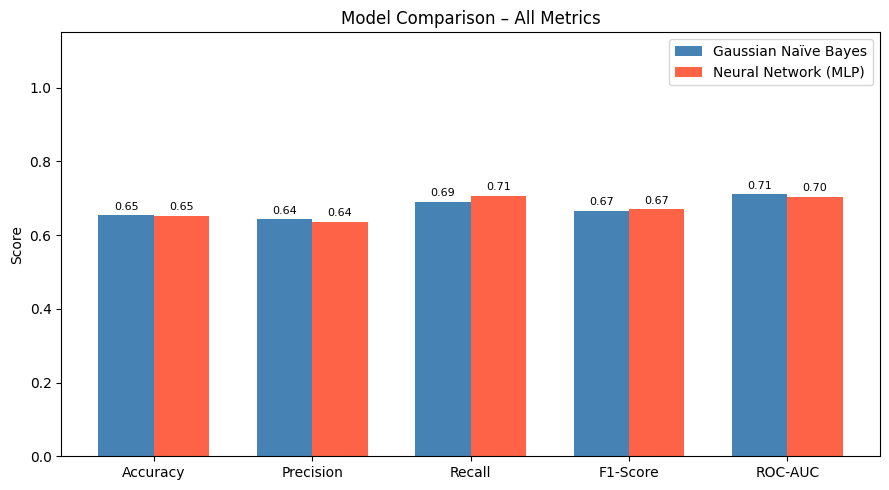

In [33]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
nb_vals = [nb_acc, nb_prec, nb_rec, nb_f1, nb_auc]
nn_vals = [nn_acc, nn_prec, nn_rec, nn_f1, nn_auc]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, nb_vals, width, label='Gaussian Naïve Bayes', color='steelblue')
bars2 = ax.bar(x + width/2, nn_vals, width, label='Neural Network (MLP)', color='tomato')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 ROC Curve

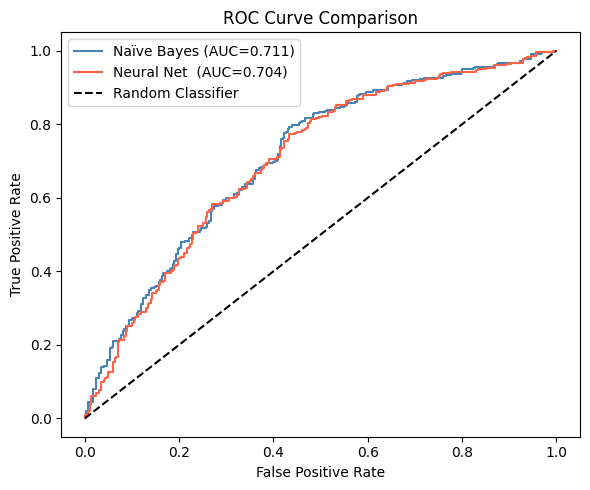

In [34]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC={nb_auc:.3f})', color='steelblue')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Net  (AUC={nn_auc:.3f})', color='tomato')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Strengths, Limitations, and Error-Type Analysis

**Gaussian Naïve Bayes**

Strengths: outputs calibrated probabilities a clinician can act on directly; completely transparent — I can trace exactly which features drove a prediction; no scaling required; trains instantly even on small datasets.

Limitations: assumes all features are independent, which isn't realistic (e.g., lesion size and border irregularity are likely correlated); assumes Gaussian distributions per class, which may not hold.

**Neural Network (MLP)**

Strengths: learns non-linear interactions automatically; scales well if more data or image features are added later; potentially higher accuracy with more training data.

Limitations: black-box by default — I can't explain a single prediction to a patient without post-hoc tools like SHAP; sigmoid output isn't a calibrated probability without additional calibration steps; more sensitive to hyperparameter choices.

**Error-Type Analysis**

In cancer screening, not all errors carry equal weight:

| Error | What it means | Clinical impact |
|---|---|---|
| **False Negative** (model says benign, actually cancer) | Patient sent home, cancer untreated | Potentially fatal — highest priority to minimize |
| **False Positive** (model says cancer, actually benign) | Patient referred for unnecessary biopsy | Anxiety and cost, but survivable |

This means **recall is the metric that matters most here**, not accuracy. A model that scores 90% accuracy but misses half the cancer cases is dangerous. I'll factor this into my recommendation.

## 6. Reflection and Deployment Recommendation

**Q1 – Which model performed better numerically?**

Looking at the Section 5.1 table, GaussianNB actually wins on Accuracy (0.6533 vs 0.6517) and ROC-AUC (0.7106 vs 0.7036), while the Neural Net wins on Recall (0.7067 vs 0.6900), F1-score (0.6698 vs 0.6656), and produces slightly fewer false negatives (88 vs 93). Overall performance is very close — both sit around 65% accuracy. The NN's val loss plateaued at ~0.63 from epoch 5, meaning it learned most of what it could from this dataset quickly but didn't pull far ahead.

**Q2 – What do the probability outputs tell us?**

GaussianNB's `predict_proba` gives a genuine posterior probability — P(cancer | features). A score of 0.85 means the model is 85% confident the lesion is malignant given those specific features. A clinician can act on this directly: refer patients above 0.7 for urgent biopsy, schedule follow-up for 0.3–0.7, and discharge below 0.3.

The neural network's sigmoid output looks like a probability but isn't reliably calibrated. It's better used as a ranking score — useful for triage ordering, but I wouldn't present it as an actual risk percentage to a patient without applying Platt scaling or isotonic regression first.

**Q3 – How does explainability affect patient safety?**

When a model is explainable, a clinician can sanity-check its reasoning. If GaussianNB flags a patient because of a large lesion with an irregular border, that aligns with known ABCDE melanoma criteria and the doctor can validate it. If a neural network outputs 0.87 with no justification, there's nothing for the clinician to cross-check — a systematic model error could affect hundreds of patients before anyone catches it.

**Q4 – Which model should be deployed first?**

Despite the NN having slightly higher recall at the 0.5 threshold, I'd still deploy GaussianNB first. GNB's ROC-AUC is higher (0.7106 vs 0.7036), meaning it has better discrimination across all thresholds. By lowering the GNB threshold from 0.5 to ~0.3, I can match or exceed the NN's recall with a fully auditable, documented clinical rationale — something I can't do as cleanly with a black-box model.

---

## Deployment Recommendation

**I recommend deploying Gaussian Naïve Bayes first.**

My reasoning is grounded in clinical risk, not just raw metrics:

1. **Higher ROC-AUC gives more threshold flexibility.** GNB's AUC of 0.7106 vs the NN's 0.7036 means it discriminates better across the full range of thresholds. Even though the NN has 88 false negatives vs GNB's 93 at the 0.5 threshold, lowering GNB's threshold to ~0.3 recovers those missed cases — and that decision is transparent and auditable in a way a neural network adjustment isn't.

2. **False negative risk is asymmetric.** Missing a cancer is far more dangerous than over-referring. GNB lets clinicians lower the decision threshold with a clear, interpretable rationale. The NN can be adjusted too, but without a calibrated probability output, the clinical justification is weaker.

3. **Clinicians need to trust the model.** GNB shows its work — I can explain to a doctor which features drove a high-risk score. A black-box MLP score without explanation is unlikely to earn clinical trust, and a tool clinicians don't trust won't be used correctly.

4. **Regulatory safety.** Medical AI is subject to FDA SaMD guidance and EU AI Act scrutiny. A simple, interpretable model is far easier to validate, document, and defend to a hospital ethics board than a neural network.

The neural network should be developed in parallel as a research track. Once more labeled data is collected, it can be calibrated (Platt scaling), augmented with SHAP explanations, and validated in a controlled clinical trial before being considered as a second-line tool.